In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("SampleSuperstore.csv", encoding='latin1')
df.head()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           ob

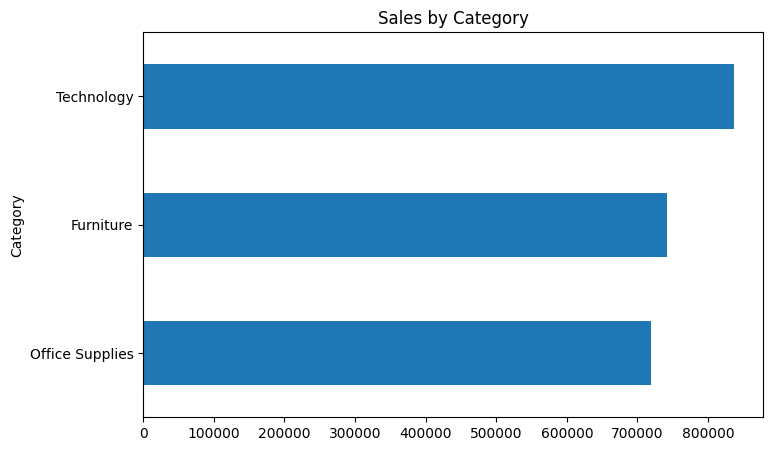

In [4]:
plt.figure(figsize=(8,5))

df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh')

plt.title("Sales by Category")

plt.savefig("Sales_by_Category.png")

plt.show()

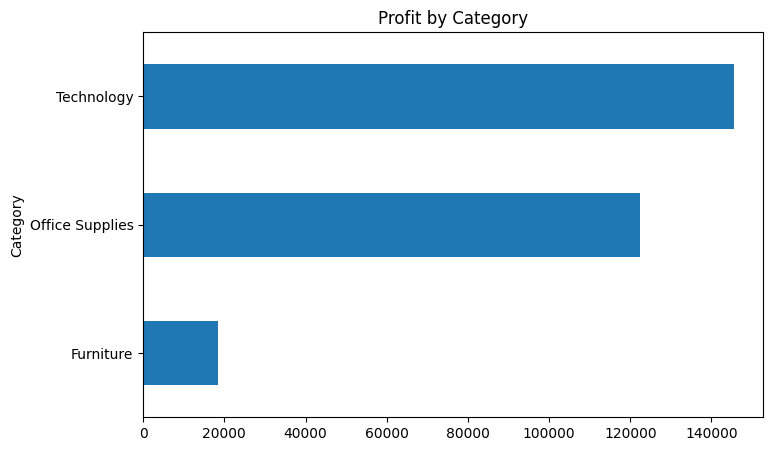

In [5]:
plt.figure(figsize=(8,5))

df.groupby('Category')['Profit'].sum().sort_values().plot(kind='barh')

plt.title("Profit by Category")

plt.savefig("Profit_by_Category.png")

plt.show()

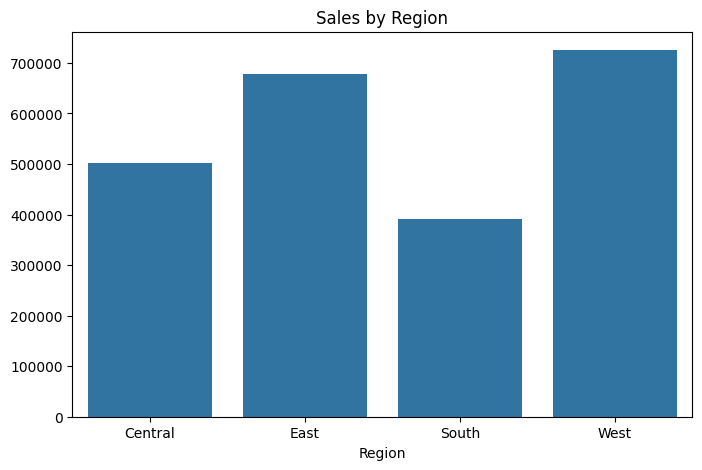

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df.groupby('Region')['Sales'].sum().index,
    y=df.groupby('Region')['Sales'].sum().values
)

plt.title("Sales by Region")

plt.savefig("Sales_by_Region.png")

plt.show()

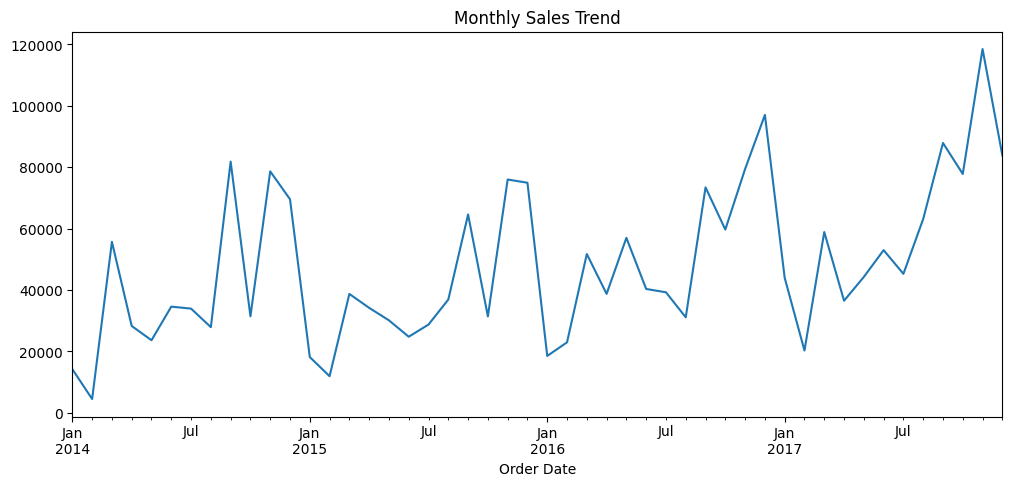

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")

plt.savefig("Monthly_Sales_Trend.png")

plt.show()

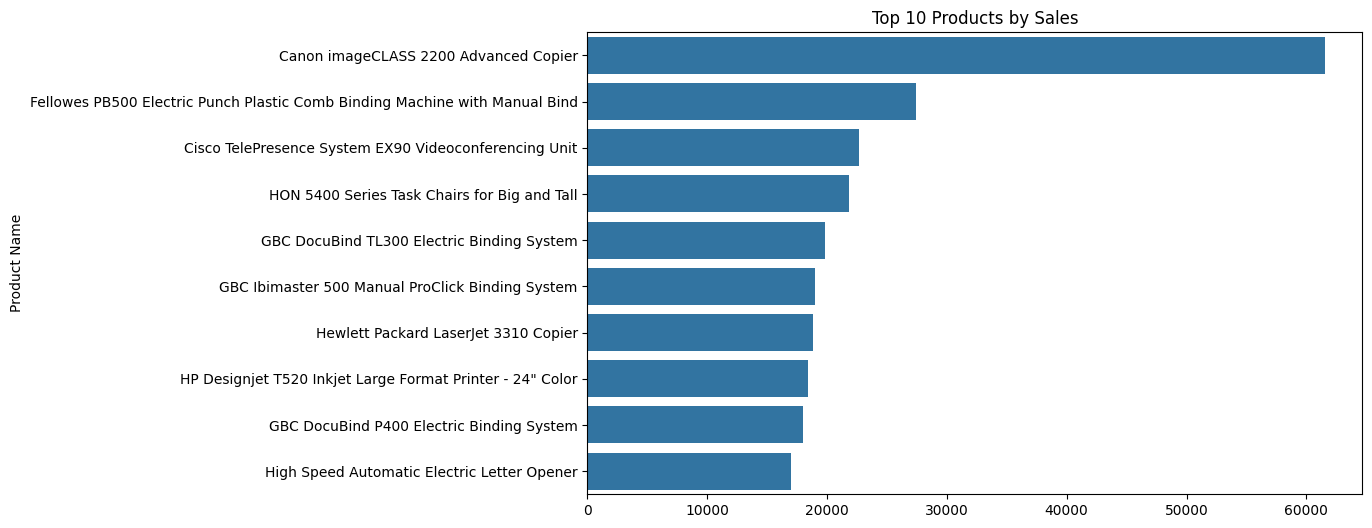

In [9]:
top_products = df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")

plt.savefig("Top_Products.png")

plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df[['Quantity','Discount']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R² Score:", r2_score(y_test,predictions))

R² Score: 0.07323561293077507


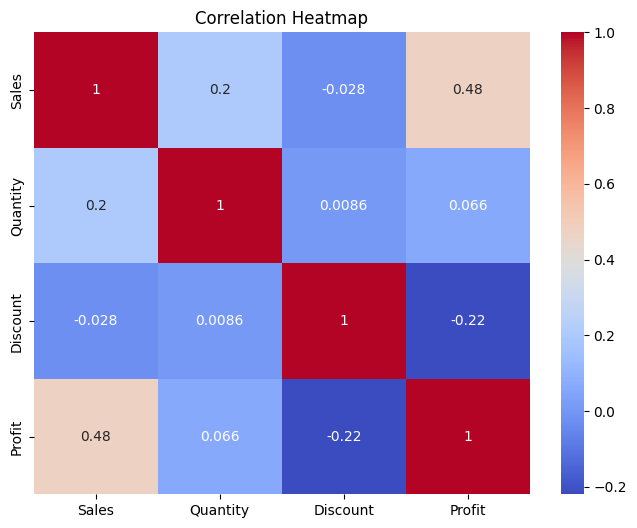

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("Correlation_Heatmap.png")

plt.show()

    Feature  Importance
0  Quantity    0.615152
1  Discount    0.384848


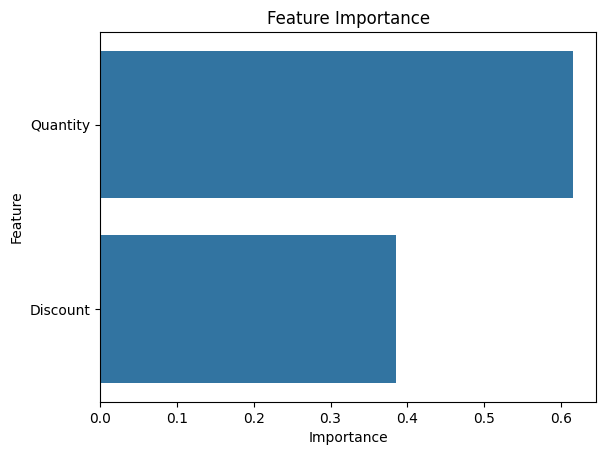

In [11]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

print(importance)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.savefig("Feature_Importance.png")

plt.show()

In [12]:
import joblib

joblib.dump(
    model,
    'sales_prediction_model.pkl'
)

print("Model Saved")

Model Saved


In [13]:
from google.colab import files

files.download('sales_prediction_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
new_data = [[5,0.1]]

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 796.4295382742259


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
